# Modul 1 Notes

In [ ]:
import re
import os

from langchain.tools import tool
from langchain_community.utilities import SQLDatabase
from langchain_ollama import ChatOllama
from langchain.agents import create_agent

In [ ]:
from dotenv import load_dotenv

load_dotenv(override=True)
print(os.getenv("LANGSMITH_API_KEY"))
print(os.getenv("LANGSMITH_TRACING"))
print(os.getenv("LANGSMITH_ENDPOINT"))
print(os.getenv("LANGSMITH_PROJECT"))
print(os.getenv("OPENAI_API_KEY"))

## Creating a Model and Agent

In [ ]:
from langchain_ollama import ChatOllama
model = ChatOllama(
    model="qwen3:1.7b", #  phi3, gemma3:12b, gpt-oss:20b, qwen3:1.7b,
    temperature=0,
    base_url="http://localhost:11434/"
)

response = model.invoke("What's the capital of the Moon?")
print(response.content)

The concept of a "capital" on celestial bodies like the moon is not applicable as it does not have an established government or inhabited regions. The idea stems from human culture and our need to identify central locations for administrative purposes, which doesn't exist in reality when we talk about extraterrestrial environments such as the Moon.


In [ ]:
from langchain.chat_models import init_chat_model

standard_model = init_chat_model(
    model="qwen3:1.7b", #  phi3, gemma3:12b, gpt-oss:20b, qwen3:1.7b,
    model_provider="ollama",  # Specify the provider
    temperature=0,
    base_url="http://localhost:11434/"
)

In [3]:
from langchain.agents import create_agent

agent = create_agent(model=model)

In [4]:
from langchain.messages import HumanMessage
from pprint import pprint # pretty print: human-readable representations of complex data structures like dictionaries, lists, and JSON objects

response = agent.invoke(
    {"messages": [HumanMessage(content="What's the capital of the Moon?")]}
)

pprint(response)

{'messages': [HumanMessage(content="What's the capital of the Moon?", additional_kwargs={}, response_metadata={}, id='73980376-45c5-4287-ba29-e5bfe289ddb1'),
              AIMessage(content='The concept of a "capital" on celestial bodies like the moon is not applicable as it does not have an established government or inhabited regions. The idea stems from human culture and our need to identify central locations for administrative purposes, which doesn\'t exist in reality when we talk about extraterrestrial environments such as the Moon.', additional_kwargs={}, response_metadata={'model': 'phi3', 'created_at': '2026-01-27T19:35:25.5270257Z', 'done': True, 'done_reason': 'stop', 'total_duration': 656424700, 'load_duration': 36241700, 'prompt_eval_count': 18, 'prompt_eval_duration': 19598900, 'eval_count': 72, 'eval_duration': 565402800, 'logprobs': None, 'model_name': 'phi3', 'model_provider': 'ollama'}, id='lc_run--019c00f4-1dad-7aa0-b6f9-4e9a73138f2b-0', tool_calls=[], invalid_tool_cal

Invoke chat with previous messages

In [5]:
from langchain.messages import AIMessage

response = agent.invoke(
    {"messages": [HumanMessage(content="What's the capital of the Moon?"),
    AIMessage(content="The capital of the Moon is Luna City."),
    HumanMessage(content="Interesting, tell me more about Luna City")]}
)

pprint(response)

{'messages': [HumanMessage(content="What's the capital of the Moon?", additional_kwargs={}, response_metadata={}, id='ecc6a272-6c95-46fc-9c0d-058d64c56a4f'),
              AIMessage(content='The capital of the Moon is Luna City.', additional_kwargs={}, response_metadata={}, id='1680a3ed-e30d-4144-92cd-5a9928f56b9c', tool_calls=[], invalid_tool_calls=[]),
              HumanMessage(content='Interesting, tell me more about Luna City', additional_kwargs={}, response_metadata={}, id='f00fb6b4-053a-424a-9f4c-e55f621c2a87'),
              AIMessage(content="Luna City stands as a testament to human ingenuity and resilience in space colonization efforts. Situated at one of the lunar poles near Shackleton Crater, it is uniquely positioned where sunlight reaches for six months straight due to its location within an overhanging crater rim that provides consistent solar energy exposure throughout much of a year on Earth's side of the Moon.\n\nThe city was designed by leading architectural firms an

## Tools

In [ ]:
from langchain.tools import tool

@tool
def square_root(x: float) -> float:
    """Calculate the square root of a number"""
    return x ** 0.5

In [ ]:
@tool("square_root")
def tool1(x: float) -> float:
    """Calculate the square root of a number"""
    return x ** 0.5

In [ ]:
@tool("square_root", description="Calculate the square root of a number")
def tool1(x: float) -> float:
    return x ** 0.5

### SQL Tool

In [ ]:
from langchain.tools import tool
from typing import Dict, Any
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("")

@tool
def sql_query(query: str) -> str:

    """Obtain information from the database using SQL queries"""

    try:
        return db.run(query)
    except Exception as e:
        return f"Error: {e}"

In [ ]:
base_path = "C:/Users/peter/Documents/SJSU/Thesis/code/mini_dev/minidev_0703/minidev/MINIDEV/dev_databases"

LLMs invoke tools through the following:

In [ ]:
tool1.invoke({"x": 467})

### Adding tools to agents

In [ ]:
from langchain.agents import create_agent

agent = create_agent(
    model=model,
    tools=[tool1, sql_query],
    system_prompt="You are an arithmetic wizard. Use your tools to calculate the square root and square of any number."
)

In [ ]:
from langchain.messages import HumanMessage

question = HumanMessage(content="What is the square root of 467?")

response = agent.invoke(
    {"messages": [question]}
)

print(response['messages'][-1].content)

In [ ]:
from pprint import pprint

pprint(response['messages'])
print(response["messages"][1].tool_calls)

## MiddleWare Matrix

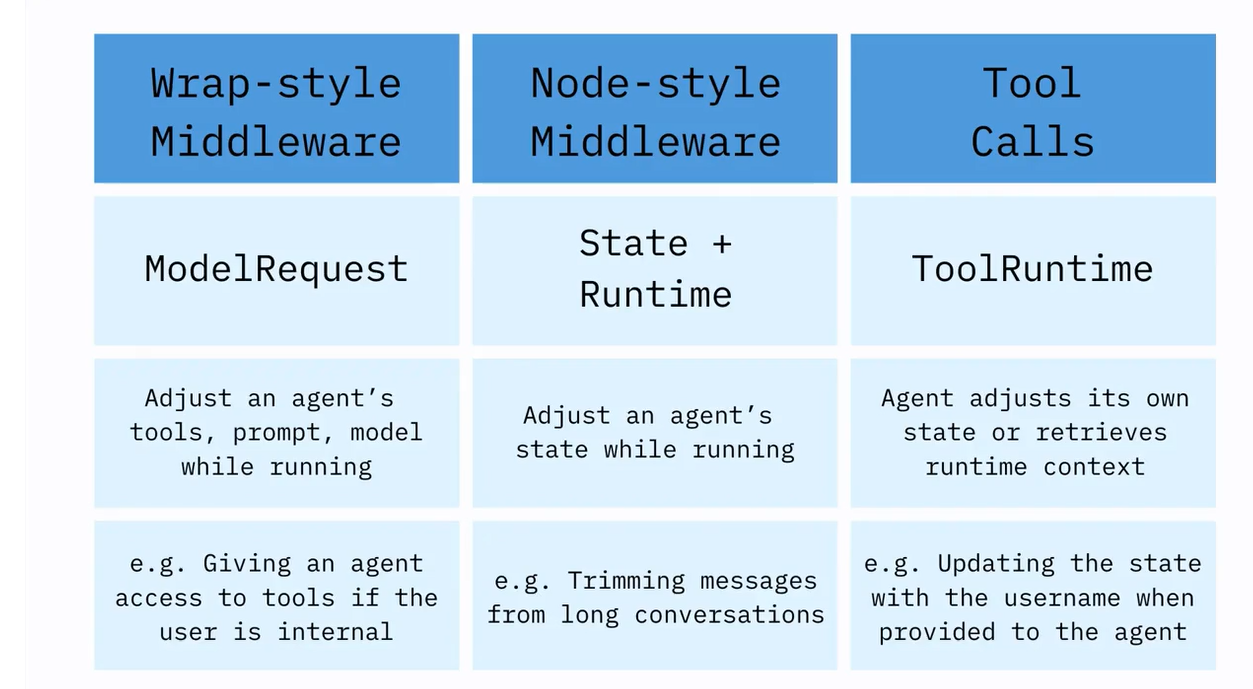